## Final Project Submission

Please fill out:
* Student name: Griffin Kinyua
* Student pace: full time
* Scheduled project review date/time: 21/08/2026
* Instructor name: Samuel G. Mwangi
* Blog post URL:


Loading im.db dataset

In [4]:
import zipfile

# Extracting im.db from the zip file inside zippedData
with zipfile.ZipFile('zippedData/im.db.zip', 'r') as zip_ref:
    zip_ref.extractall('zippedData/')

Connecting to the SQLite Database

In [5]:
import sqlite3
import pandas as pd

# Connecting to the unzipped SQLite database
conn = sqlite3.connect('zippedData/im.db')

Inspecting the dataset

Checking the tables in the dataset

In [6]:
# Listing all tables in the database
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query, conn)
display(tables)

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [7]:
# Loading the FULL table into Pandas 
movies_df = pd.read_sql('SELECT * FROM movie_basics;', conn)

# Checking missing values across ALL rows
print(movies_df.isnull().sum())

# Inspecting a sample of 10 rows in Pandas instead of SQL
display(movies_df.head(10))

conn.close()

movie_id               0
primary_title          0
original_title        21
start_year             0
runtime_minutes    31739
genres              5408
dtype: int64


,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"
5,tt0111414,A Thin Life,A Thin Life,2018,75.0,Comedy
6,tt0112502,Bigfoot,Bigfoot,2017,NaN,"Horror,Thriller"
7,tt0137204,Joe Finds Grace,Joe Finds Grace,2017,83.0,"Adventure,Animation,Comedy"
8,tt0139613,O Silêncio,O Silêncio,2012,NaN,"Documentary,History"
9,tt0144449,Nema aviona za Zagreb,Nema aviona za Zagreb,2012,82.0,Biography


Splitting the genres columns into individual genre rows

In [8]:
# Connect to database and load tables
conn = sqlite3.connect('zippedData/im.db')
movie_basics = pd.read_sql("SELECT * FROM movie_basics;", conn)
movie_ratings = pd.read_sql("SELECT * FROM movie_ratings;", conn)

# Merging tables and filter valid rows to build cleaned_df
cleaned_df = pd.merge(movie_basics, movie_ratings, on='movie_id', how='inner')
cleaned_df = cleaned_df[cleaned_df['numvotes'] >= 100].dropna(subset=['genres'])

# Split comma-separated genres and explode into individual rows
df_genres_exploded = cleaned_df.assign(
    genre=cleaned_df['genres'].str.split(',')
).explode('genre')

# Strip extra whitespace around genre names
df_genres_exploded['genre'] = df_genres_exploded['genre'].str.strip()

# Preview the exploded dataframe
display(df_genres_exploded[['primary_title', 'genres', 'genre', 'averagerating', 'numvotes']].head(10))

,primary_title,genres,genre,averagerating,numvotes
2,The Other Side of the Wind,Drama,Drama,6.9,4517
4,The Wandering Soap Opera,"Comedy,Drama,Fantasy",Comedy,6.5,119
4,The Wandering Soap Opera,"Comedy,Drama,Fantasy",Drama,6.5,119
4,The Wandering Soap Opera,"Comedy,Drama,Fantasy",Fantasy,6.5,119
6,Joe Finds Grace,"Adventure,Animation,Comedy",Adventure,8.1,263
6,Joe Finds Grace,"Adventure,Animation,Comedy",Animation,8.1,263
6,Joe Finds Grace,"Adventure,Animation,Comedy",Comedy,8.1,263
7,Pál Adrienn,Drama,Drama,6.8,451
10,Children of the Green Dragon,Drama,Drama,6.9,120
12,The Tragedy of Man,"Animation,Drama,History",Animation,7.8,584


Now that each row represents a single movie-genre pairing, we group by genre to aggregate performance metrics across genres

In [9]:
# Calculating average rating, total votes, and movie count per genre
genre_summary = df_genres_exploded.groupby('genre').agg(
    avg_rating=('averagerating', 'mean'),
    total_votes=('numvotes', 'sum'),
    movie_count=('primary_title', 'count')
).reset_index().sort_values(by='avg_rating', ascending=False)

display(genre_summary)

,genre,avg_rating,total_votes,movie_count
17,News,7.130088,112430,113
7,Documentary,7.086684,4419900,3537
4,Biography,6.883847,21552395,1461
14,Music,6.701406,5420397,711
12,History,6.668123,7798403,1007
21,Sport,6.600387,3737919,517
3,Animation,6.309133,15325900,865
23,War,6.262562,2672421,406
15,Musical,6.216532,1375198,248
8,Drama,6.161747,119069859,13803


Calculating profit (Profit = WW Gross - Production Budgety)

In [10]:
# Loading the budget dataset
budgets_df = pd.read_csv('zippedData/tn.movie_budgets.csv.gz')

# Cleaning currency strings by removing '$' and ',' then converting to float
financial_cols = ['production_budget', 'worldwide_gross']

for col in financial_cols:
    budgets_df[col] = (
        budgets_df[col]
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

# Calculating profit (WW Gross - production budget)
budgets_df['profit'] = budgets_df['worldwide_gross'] - budgets_df['production_budget']

# Previewing the top 5 profitable movies
display(budgets_df[['movie', 'production_budget', 'worldwide_gross', 'profit']].head())

,movie,production_budget,worldwide_gross,profit
0,Avatar,425000000.0,2.776345e+09,2.351345e+09
1,Pirates of the Caribbean: On Stranger Tides,410600000.0,1.045664e+09,6.350639e+08
2,Dark Phoenix,350000000.0,1.497624e+08,-2.002376e+08
3,Avengers: Age of Ultron,330600000.0,1.403014e+09,1.072414e+09
4,Star Wars Ep. VIII: The Last Jedi,317000000.0,1.316722e+09,9.997217e+08


Key Highlights of that step is:
String Cleaning: Financial figures in raw data are formatted as text (e.g., "$100,000,000"). Stripping the dollar dign and prevents TypeError math exceptions.

New Column: The resulting profit column contains exact net gain values in numeric format, ready for sorting, aggregation, or merging with your IMDb genre dataset.

In [11]:
# displaying the output as formatted currency
pd.options.display.float_format = '${:,.2f}'.format

display(budgets_df[['movie', 'production_budget', 'worldwide_gross', 'profit']].head())

,movie,production_budget,worldwide_gross,profit
0,Avatar,"$425,000,000.00","$2,776,345,279.00","$2,351,345,279.00"
1,Pirates of the Caribbean: On Stranger Tides,"$410,600,000.00","$1,045,663,875.00","$635,063,875.00"
2,Dark Phoenix,"$350,000,000.00","$149,762,350.00","$-200,237,650.00"
3,Avengers: Age of Ultron,"$330,600,000.00","$1,403,013,963.00","$1,072,413,963.00"
4,Star Wars Ep. VIII: The Last Jedi,"$317,000,000.00","$1,316,721,747.00","$999,721,747.00"


Exporting clean merged data for tableau

In [12]:
# Merging exploded genre/ratings data with budget & profit data
# Matching on movie titles ('primary_title' from IMDb and 'movie' from budget dataset)
tableau_df = pd.merge(
    df_genres_exploded, 
    budgets_df, 
    left_on='primary_title', 
    right_on='movie', 
    how='inner'
)

# Selecting and cleaning relevant columns for Tableau visualizations
tableau_export = tableau_df[[
    'movie', 'release_date', 'genre', 'averagerating', 
    'numvotes', 'production_budget', 'worldwide_gross', 'profit'
]].drop_duplicates()

# Exporting to CSV file ready for Tableau
tableau_export.to_csv('cleaned_movie_data_for_tableau.csv', index=False)

print(f"Export successful! Saved {tableau_export.shape[0]} rows to 'cleaned_movie_data_for_tableau.csv'")
display(tableau_export.head())

Export successful! Saved 5442 rows to 'cleaned_movie_data_for_tableau.csv'


,movie,release_date,genre,averagerating,numvotes,production_budget,worldwide_gross,profit
0,Foodfight!,"Dec 31, 2012",Action,$1.90,8248,"$45,000,000.00","$73,706.00","$-44,926,294.00"
1,Foodfight!,"Dec 31, 2012",Animation,$1.90,8248,"$45,000,000.00","$73,706.00","$-44,926,294.00"
2,Foodfight!,"Dec 31, 2012",Comedy,$1.90,8248,"$45,000,000.00","$73,706.00","$-44,926,294.00"
3,On the Road,"Mar 22, 2013",Adventure,$6.10,37886,"$25,000,000.00","$9,313,302.00","$-15,686,698.00"
4,On the Road,"Mar 22, 2013",Drama,$6.10,37886,"$25,000,000.00","$9,313,302.00","$-15,686,698.00"


From the output, we can see the averagerating column is formatted as currency since we ran pd.options.display.float_format = '${:,.2f}'.format in a previous cell.
Tableau needs numerical values rather than text strings so it can calculate metrics.

In [13]:
# Resetting float formatting so ratings display as raw numbers instead of currency
pd.reset_option('display.float_format')

# Display the dataframe preview to verify
display(tableau_export.head())

,movie,release_date,genre,averagerating,numvotes,production_budget,worldwide_gross,profit
0,Foodfight!,"Dec 31, 2012",Action,1.9,8248,45000000.0,73706.0,-44926294.0
1,Foodfight!,"Dec 31, 2012",Animation,1.9,8248,45000000.0,73706.0,-44926294.0
2,Foodfight!,"Dec 31, 2012",Comedy,1.9,8248,45000000.0,73706.0,-44926294.0
3,On the Road,"Mar 22, 2013",Adventure,6.1,37886,25000000.0,9313302.0,-15686698.0
4,On the Road,"Mar 22, 2013",Drama,6.1,37886,25000000.0,9313302.0,-15686698.0


Creating studio level aggregation table. Avg gross per studio

In [ ]:
import pandas as pd

# Load Box Office dataset 
bom_df = pd.read_csv('zippedData/bom.movie_gross.csv.gz')

# Merge budgets_df with bom_df on title
df_with_studios = pd.merge(
    budgets_df, 
    bom_df[['title', 'studio']], 
    left_on='movie', 
    right_on='title', 
    how='inner'
)

# Group by studio and calculate average gross, average profit, and movie counts
studio_agg = df_with_studios.groupby('studio').agg(
    avg_worldwide_gross=('worldwide_gross', 'mean'),
    avg_profit=('profit', 'mean'),
    movie_count=('movie', 'count')
).reset_index()

# Sort by highest average worldwide gross
studio_agg = studio_agg.sort_values(by='avg_worldwide_gross', ascending=False)

# Format numbers to Millions ($M)
studio_agg['avg_worldwide_gross_mil'] = (studio_agg['avg_worldwide_gross'] / 1_000_000).round(2)
studio_agg['avg_profit_mil'] = (studio_agg['avg_profit'] / 1_000_000).round(2)

# Display top 10 studios
display(studio_agg[['studio', 'movie_count', 'avg_worldwide_gross_mil', 'avg_profit_mil']].head(10))

,studio,movie_count,avg_worldwide_gross_mil,avg_profit_mil
64,P/DW,10,507.80,374.40
15,BV,72,462.31,331.04
38,GrtIndia,1,263.50,233.50
32,Fox,110,243.60,173.09
82,Sony,74,237.86,169.61
90,Uni.,117,233.58,177.19
95,WB (NL),37,230.83,172.76
94,WB,102,217.59,137.22
69,Par.,74,195.11,130.65
83,Strand,1,174.28,129.28


In [17]:
# Ensuring budgets_df has profit calculated
if 'profit' not in budgets_df.columns:
    budgets_df['profit'] = budgets_df['worldwide_gross'] - budgets_df['production_budget']

# Merging df_genres_exploded with budgets_df
merged_genres = pd.merge(
    df_genres_exploded,
    budgets_df[['movie', 'production_budget', 'worldwide_gross', 'profit']],
    left_on='primary_title',
    right_on='movie',
    how='inner'
)

# Calculating ROI (%)
merged_genres['roi'] = (merged_genres['profit'] / merged_genres['production_budget']) * 100

# Group by genre to get average ROI and average rating
genre_agg = merged_genres.groupby('genres').agg(
    avg_roi=('roi', 'mean'),
    avg_rating=('averagerating', 'mean'),
    movie_count=('genres', 'count')
).reset_index()

# Round and sort by highest average ROI
genre_agg['avg_roi'] = genre_agg['avg_roi'].round(2)
genre_agg['avg_rating'] = genre_agg['avg_rating'].round(2)
genre_agg = genre_agg.sort_values(by='avg_roi', ascending=False)

display(genre_agg)

,genres,avg_roi,avg_rating,movie_count
120,"Biography,Documentary",10311.81,7.2,6
210,"Drama,Family,Fantasy",4726.02,6.9,6
187,"Crime,Drama,Family",3352.97,6.3,6
205,"Documentary,Sport",3087.40,7.9,4
265,"Horror,Mystery,Thriller",2396.45,5.4,123
...,...,...,...,...
178,"Comedy,Romance,Thriller",-100.00,4.1,3
112,"Animation,Family",-100.00,6.2,2
206,"Documentary,Sport,Thriller",-100.00,7.9,3
262,"Horror,Musical",-100.00,6.9,2


Building visualisations; ROI BY GENRE

C:\Users\hp\AppData\Local\Temp\ipykernel_12744\918391495.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


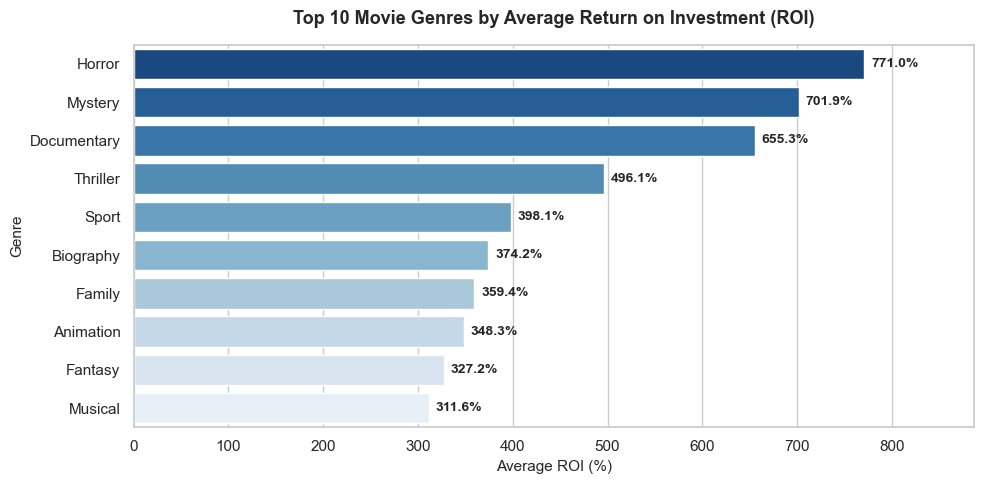

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separate comma-separated genre strings into individual rows
df_exploded = merged_genres.copy()
df_exploded['genres'] = df_exploded['genres'].str.split(',')
df_exploded = df_exploded.explode('genres')
df_exploded['genres'] = df_exploded['genres'].str.strip()

# 2. Group by single genre and aggregate (requiring at least 5 movies to remove random outliers)
genre_summary = df_exploded.groupby('genres').agg(
    avg_roi=('roi', 'mean'),
    movie_count=('roi', 'count')
).reset_index()

# Filter for genres with a reasonable sample size and pick Top 10
top_genres = genre_summary[genre_summary['movie_count'] >= 5].sort_values(by='avg_roi', ascending=False).head(10)

# 3. Plot clean horizontal bar chart
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=top_genres,
    x='avg_roi',
    y='genres',
    palette='Blues_r'
)

# Add clear data labels
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{width:,.1f}%',
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Top 10 Movie Genres by Average Return on Investment (ROI)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Average ROI (%)', fontsize=11)
plt.ylabel('Genre', fontsize=11)
plt.xlim(0, top_genres['avg_roi'].max() * 1.15)

plt.tight_layout()
plt.show()

Building visualization ; budget tier vs profit

C:\Users\hp\AppData\Local\Temp\ipykernel_12744\1727109470.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


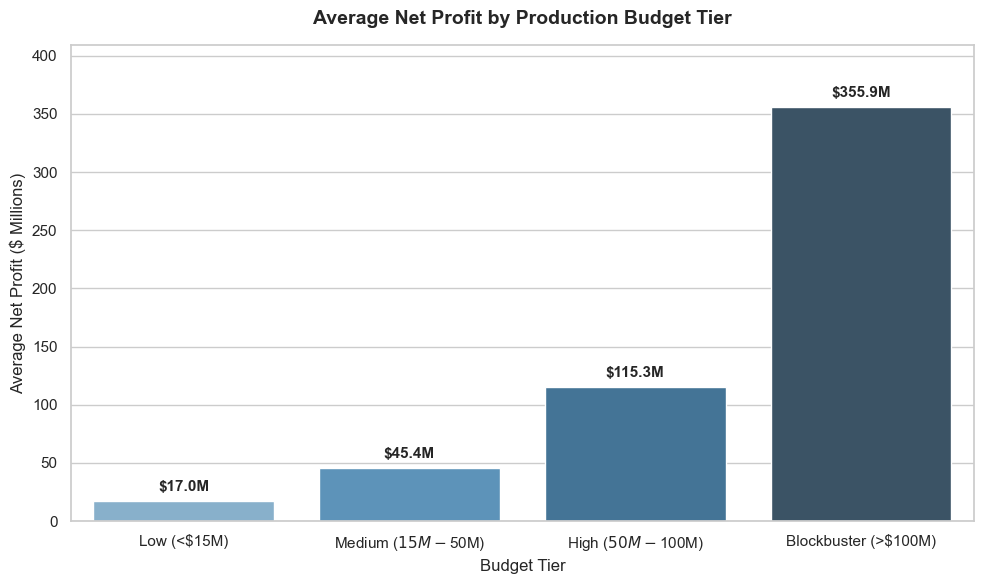

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure profit column exists (Worldwide Gross - Production Budget)
if 'profit' not in budgets_df.columns:
    budgets_df['profit'] = budgets_df['worldwide_gross'] - budgets_df['production_budget']

# 2. Define budget tiers
budget_bins = [0, 15_000_000, 50_000_000, 100_000_000, float('inf')]
budget_labels = ['Low (<$15M)', 'Medium ($15M-$50M)', 'High ($50M-$100M)', 'Blockbuster (>$100M)']

budgets_df['budget_tier'] = pd.cut(
    budgets_df['production_budget'], 
    bins=budget_bins, 
    labels=budget_labels
)

# 3. Express profit in Millions ($M) and aggregate average profit per tier
budgets_df['profit_mil'] = budgets_df['profit'] / 1_000_000
tier_summary = budgets_df.groupby('budget_tier', observed=False)['profit_mil'].mean().reset_index()

# 4. Plot bar chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=tier_summary,
    x='budget_tier',
    y='profit_mil',
    palette='Blues_d'
)

# 5. Add exact value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.annotate(
            f'${height:,.1f}M',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            xytext=(0, 5),
            textcoords='offset points',
            fontsize=11,
            fontweight='bold'
        )

# Format titles and labels
plt.title('Average Net Profit by Production Budget Tier', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Budget Tier', fontsize=12)
plt.ylabel('Average Net Profit ($ Millions)', fontsize=12)
plt.ylim(0, tier_summary['profit_mil'].max() * 1.15)

plt.tight_layout()
plt.show()